In [1]:
# ==================
# Imports and Setup
# ==================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# -----------------
# Load the Data
# -----------------

df = pd.read_csv("ASAP2_train_sourcetexts.csv")

print(df.shape)
df.head()

(24728, 14)


,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


In [3]:
# -------------------
# Seed Optimization
# -------------------

df = df.sample(5000, random_state=42).reset_index(drop=True)

In [5]:
# ======================
# Feature Engineering
# ======================

df["word_count"] = df["full_text"].astype(str).apply(lambda x: len(x.split()))

def vocab_richness(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df["vocab_richness"] = df["full_text"].astype(str).apply(vocab_richness)

# Feature Matrix

feature_cols = ["word_count", "vocab_richness"]

X_features = df[feature_cols].fillna(0)

# Normalize Features

scaler = MinMaxScaler()
X_features_scaled = scaler.fit_transform(X_features)

In [6]:
# ----------------------------
# Create Semantic Embeddings
# ----------------------------

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df["full_text"].astype(str).tolist(),
    show_progress_bar=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [12]:
# ==========================
# Define Retrieval Function
# ==========================

def retrieve_similar_essays(new_text, top_k=5):

    # Step 1: Embed new essay
    new_embedding = model.encode([new_text])

    # Step 2: Semantic similarity
    semantic_sim = cosine_similarity(new_embedding, embeddings)[0]

    # Step 3: Feature similarity
    new_word_count = len(new_text.split())
    new_vocab = vocab_richness(new_text)

    new_features = scaler.transform([[new_word_count, new_vocab]])

    feature_sim = cosine_similarity(new_features, X_features_scaled)[0]

    # Step 4: Hybrid score
    # Weighted towards semantic similarity while not taking away from feature importance
    # More weight is assigned to semantics, as word count can be score distorting in extrema
    final_score = 0.6 * semantic_sim + 0.4 * feature_sim

    # Step 5: Get top K
    top_indices = np.argsort(final_score)[-top_k:][::-1]

    results = df.iloc[top_indices].copy()

    results["semantic_similarity"] = semantic_sim[top_indices]
    results["feature_similarity"] = feature_sim[top_indices]
    results["final_score"] = final_score[top_indices]

    return results

In [13]:
# --------------------
# Test Retrieval
# --------------------

test_essay = df["full_text"].iloc[0]

results = retrieve_similar_essays(test_essay, top_k=3)

results[["full_text", "score", "final_score"]]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


,full_text,score,final_score
0,Driverless cars are a good inovention for the ...,3,1.000000
2209,In my opinion driverless cars are safer and mo...,4,0.921845
4423,"In ""Driverless Cars Are Coming,"" there are sev...",5,0.916353


In [14]:
# ------------------
# Readible Output
# ------------------

def display_results(results):
    for i, row in results.iterrows():
        print("="*80)
        print(f"Score: {row['score']}")
        print(f"Final Similarity: {row['final_score']:.3f}")
        print("-"*80)
        print(row["full_text"][:500])  # preview
        print("\n")

# Sanity Check
display_results(results)

Score: 3
Final Similarity: 1.000
--------------------------------------------------------------------------------
Driverless cars are a good inovention for the future. Driverless cars can help effect safety,traffic, and the polution in the air. Driverless cars could help communities and the economy in many ways.

Driverless cars could change the way people commute. As driverless cars begin to come in play, less people will have to drive their own car. As many people know, tons people get into accidents everyday because of the people behind the wheel making harmful decisions, if driverless cars were put out 


Score: 4
Final Similarity: 0.922
--------------------------------------------------------------------------------
In my opinion driverless cars are safer and more efficien than nomal car.In paragraph five of the passage it says, "the sensors can cause the car to apply brakes on individual wheels and ruduce power from the engine,allowing far better response and control than a human

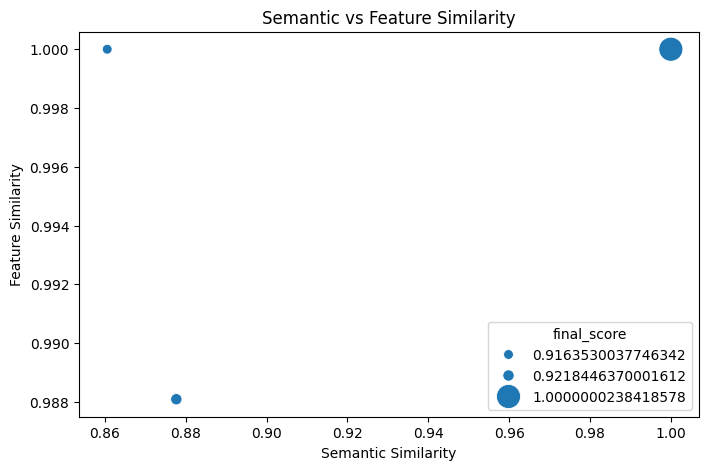

In [15]:
# ======================
# Visualization
# ======================

# Similarity Breakdown
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=results["semantic_similarity"],
    y=results["feature_similarity"],
    size=results["final_score"],
    sizes=(50, 300)
)

plt.title("Semantic vs Feature Similarity")
plt.xlabel("Semantic Similarity")
plt.ylabel("Feature Similarity")

plt.show()

In [16]:
# ----------------------
# Save Retrieval Base
# ----------------------

np.save("essay_embeddings.npy", embeddings)
df.to_csv("rag_base_dataset.csv", index=False)